# Airsim基本Python-API控制

Airsim的其他开源仿真场景：https://github.com/microsoft/airsim/releases

Airsim的官方帮助文档：https://microsoft.github.io/AirSim/coding_guidelines/

国内目前最好的Airsim入门教程：https://www.bilibili.com/video/BV1Ec411N7iu?spm_id_from=333.788.videopod.sections&vd_source=15c0f0127db755ea4381befc37ac30c1


# 1.环境初始化与无人机初始API指令

In [2]:
#pip install numpy #安装numpy库，NumPy（Numerical Python）是 Python 中用于科学计算的核心库，主要用于阵运算、多维数组计算，很多 AI 项目底层都会使用 NumPy。

In [3]:
#导入 sys 模块。将 ../external-libraries (..表示上一级目录）添加到 Python 的模块搜索路径。这样可以导入放在该目录中的库（例如 AirSim 源码），即使它们没有通过 pip 安装。
import sys
sys.path.append('../external-libraries')
import airsim
import math
import numpy as np

In [36]:
#连接airsim模拟器并反馈连接状态，其中client = airsim.MultirotorClient()内可以写ip地址，不写默认连接本地，写了就是连接到目标地址的对应机器
client = airsim.MultirotorClient()
client.confirmConnection()
#获取API控制权限并查询
client.enableApiControl(True)
client.isApiControlEnabled()

Connected!
Client Ver:1 (Min Req: 1), Server Ver:1 (Min Req: 1)



True

In [37]:
#无人机起飞， Async/异步作为后缀，执行的时候会立即返回，不阻塞
# 但命令本身还是顺序执行的，所以需要join等待命令执行完毕，上一个命令执行完成，才会执行下一个命令
client.takeoffAsync().join()

In [28]:
#无人机降落
client.landAsync().join()

In [32]:
#无人机上锁
client.armDisarm(False)

False

In [30]:
#无人机悬停
client.hoverAsync().join()

# 2.无人机位置控制
Airsim使用NED坐标系
| 方向 | 坐标 |
| -- | -- |
| 前方 | X+ |
| 右侧 | Y+ |
| 下降 | Z+ |
| 上升 | Z- |
单位：米


# 飞到指定位置

In [ ]:
client.moveToPositionAsync(
    x,
    y,
    z,
    velocity
).join()

In [59]:
client.moveToPositionAsync(
    10,
    0,
    -5,
    3
).join()

# 速度控制

In [ ]:
client.moveByVelocityAsync(
    vx,
    vy,
    vz,
    duration
)

In [38]:
client.moveByVelocityAsync(
    0,
    0,
    -1,
    2
).join()

# 速度＋偏航控制

In [ ]:
client.moveByVelocityZAsync(
    vx,
    vy,
    z,
    duration
)

In [40]:
client.moveByVelocityZAsync(
    1,
    0,
    -2,
    2
).join()

# 偏航角控制

In [ ]:
client.rotateToYawAsync(
    yaw
)

In [50]:
client.rotateToYawAsync(
    60
).join()

# 3.获取无人机状态

在AirSim中，`simGetGroundTruthKinematics` 和 `simGetVehiclePose` 都是获取无人机状态的接口，但**返回数据的精度、用途和底层含义有本质区别**。以下是两者的详细对比：

---

### **1. `simGetVehiclePose()`**
- **功能**：获取无人机的**位姿（Pose）**，即位置和姿态。
- **返回数据**：
  ```python
  Pose(
      position=Vector3r(x, y, z),  # 位置（NED坐标系，单位：米）
      orientation=Quaternionr(w, x, y, z)  # 四元数姿态（相对世界坐标系）
  )
  ```
- **特点**：
  - 数据来源于仿真的**传感器模型**（如GPS、IMU），可能包含噪声。
  - 模拟真实无人机传感器输出的结果，适合测试SLAM、导航等算法。
  - 如果AirSim设置中启用了传感器噪声（默认关闭），返回的坐标会有扰动。

---

### **2. `simGetGroundTruthKinematics()`**
- **功能**：获取无人机的**真实运动学状态**（Ground Truth）。
- **返回数据**：
  ```python
  KinematicsState(
      position=Vector3r(x, y, z),  # 位置（绝对精确，NED坐标系）
      orientation=Quaternionr(w, x, y, z),  # 姿态（绝对精确）
      linear_velocity=Vector3r(vx, vy, vz),  # 线速度（米/秒）
      angular_velocity=Vector3r(wx, wy, wz),  # 角速度（弧度/秒）
      linear_acceleration=Vector3r(ax, ay, az),  # 线加速度（米/秒²）
      angular_acceleration=Vector3r(αx, αy, αz)  # 角加速度（弧度/秒²）
  )
  ```
- **特点**：
  - 数据来源于仿真的**物理引擎**，是绝对精确的“上帝视角”数据，无任何噪声。
  - 适合用于**算法验证**（如对比传感器数据与真实值的误差）或**控制算法设计**（如直接获取速度反馈）。

---

### **3. 关键区别总结**
| 特性                | `simGetVehiclePose()`              | `simGetGroundTruthKinematics()`    |
|--------------------|-----------------------------------|-----------------------------------|
| 数据来源             | 传感器模型（可能含噪声）            | 物理引擎（绝对精确）                |
| 数据维度             | 仅位置和姿态                      | 位置、姿态、速度、加速度            |
| 用途                | 模拟真实传感器输出                 | 算法验证、控制闭环设计              |
| 计算开销            | 低（仅读取传感器数据）              | 高（需从物理引擎获取完整状态）       |

---

### **4. 使用场景建议**
- **需要传感器级数据**（如测试SLAM、避障）：  
  使用 `simGetVehiclePose()`，并启用传感器噪声（通过AirSim的[设置文件](https://microsoft.github.io/AirSim/settings/)配置）。

- **需要真实状态验证**（如控制器调试、轨迹跟踪）：  
  使用 `simGetGroundTruthKinematics().position` 或 `linear_velocity`。

- **需要动力学参数**（如速度反馈、加速度前馈）：  
  直接读取 `linear_velocity` 和 `linear_acceleration`。

In [61]:
import time
#moveToZAsync，坐标系是NED，所以正数是向上，负数是向下
client.moveToZAsync(-3, 1).join()   # 上升到3米高度，1是速度

for i in range(2):
    kinematic_state_groundtruth = client.simGetGroundTruthKinematics(vehicle_name='')
    #print("kinematic_state_groundtruth: ", kinematic_state_groundtruth)

    # state_groundtruth 的6个属性
    print(
    "position", kinematic_state_groundtruth.position,  # 位置信息
    "\n\n linear_velocity", kinematic_state_groundtruth.linear_velocity,  # 速度信息
    "\n\n linear_acceleration", kinematic_state_groundtruth.linear_acceleration , # 加速度信息
    "\n\n orientation", kinematic_state_groundtruth.orientation,  # 姿态信息
    "\n\n angular_velocity", kinematic_state_groundtruth.angular_velocity,  # 姿态角速率信息
    "\n\n angular_acceleration", kinematic_state_groundtruth.angular_acceleration,  # 姿态角加速度信息
    )

    # 无人机全局位置坐标真值
    x = kinematic_state_groundtruth.position.x_val  # 全局坐标系下，x轴方向的坐标
    y = kinematic_state_groundtruth.position.y_val  # 全局坐标系下，y轴方向的坐标
    z = kinematic_state_groundtruth.position.z_val  # 全局坐标系下，z轴方向的坐标
    print("x: ", x, "y: ", y, "z: ", z)

    time.sleep(1)
    print("-----------------------------------------------------------------------------------")

position <Vector3r> {   'x_val': 9.988344192504883,
    'y_val': 0.02372477948665619,
    'z_val': -3.382310152053833} 

 linear_velocity <Vector3r> {   'x_val': -0.003128930926322937,
    'y_val': -0.001899524126201868,
    'z_val': -3.950160680687986e-05} 

 linear_acceleration <Vector3r> {   'x_val': -0.0014697621809318662,
    'y_val': 0.0023472874891012907,
    'z_val': 0.0} 

 orientation <Quaternionr> {   'w_val': 0.8884042501449585,
    'x_val': 0.00014075535000301898,
    'y_val': 1.1313258255540859e-05,
    'z_val': 0.45906201004981995} 

 angular_velocity <Vector3r> {   'x_val': -7.96788081061095e-05,
    'y_val': -0.0001999287196667865,
    'z_val': 9.768380770935892e-09} 

 angular_acceleration <Vector3r> {   'x_val': -0.00014189074863679707,
    'y_val': 8.154168608598411e-05,
    'z_val': 2.594262014099513e-07}
x:  9.988344192504883 y:  0.02372477948665619 z:  -3.382310152053833
-----------------------------------------------------------------------------------
position 

In [62]:
pose = client.simGetVehiclePose()
print(pose)

<Pose> {   'orientation': <Quaternionr> {   'w_val': 0.8884041905403137,
    'x_val': 0.00011187305790372193,
    'y_val': -0.0002182705356972292,
    'z_val': 0.45906198024749756},
    'position': <Vector3r> {   'x_val': 9.980829238891602,
    'y_val': 0.021202627569437027,
    'z_val': -3.382314920425415}}


# 4.AirSim 无人机视觉感知

AirSim 是一款基于虚幻引擎开发的开源模拟器，在无人机开发中，其摄像头数据采集功能至关重要。


### 支持多种摄像头类型

AirSim 支持多种常见摄像头类型，如场景摄像头（用于获取无人机视角下的彩色图像）、深度摄像头（可生成场景的深度信息，帮助无人机感知距离）以及鱼眼摄像头（提供更广阔的视野范围，适用于全景数据采集）。开发者能依据具体的开发需求，轻松在代码中选择并配置所需的摄像头类型。

### 灵活的数据采集配置

开发者可对摄像头参数进行精细设置，像图像分辨率（例如从低分辨率的 320x240 到高分辨率的 4K 甚至更高）、帧率（可根据任务需求调整，如对于实时性要求高的跟踪任务，可设置较高帧率）、视野角度等。同时，还能指定数据采集的频率，是按固定时间间隔采集，还是在特定事件触发时采集，这为不同的应用场景提供了极大的灵活性。

### 便捷的数据获取方式

在代码层面，通过 AirSim 提供的 API，开发者能以简单的函数调用获取摄像头数据。例如在 Python 环境中，使用 airsim.MultirotorClient 类的方法，先连接到 AirSim 模拟器，再通过相应指令获取摄像头图像数据。这些数据以常见的图像格式（如 PNG、JPEG 用于彩色图像，或特殊格式用于深度图像数据）返回，方便后续使用 OpenCV 等图像处理库进行分析和处理。



AirSim 平台中的无人机和无人车都默认放有 5 个相机，只是位置不同，本书主要介绍无人机上的相机。下表列出的是相机的位置和命名。旧版本的 AirSim 对相机的命名是使用的数字，目前 AirSim 兼容旧版本，所以使用数字也是可以的。

| 相机位置     | ID                | 旧版本ID      |
|--------------|-------------------|---------------|
| 前向中间     | `"front_center"`  | `"0"`         |
| 前向右边     | `"front_right"`   | `"1"`         |
| 前向左边     | `"front_left"`    | `"2"`         |
| 底部中间     | `"bottom_center"` | `"3"`         |
| 后向中间     | `"back_center"`   | `"4"`         |

<img src="img/s1-4-1.png" width="600px" />

<img src="img/s1-4-2.png" width="600px" />

AirSim 中默认可以获得 8 种不同类型的图片，下表总结了这10中类型图片的名称、解释和调用方式。

| 图像类型            | 解释                                                                 | 调用方式                          |
|---------------------|--------------------------------------------------------------------|-----------------------------------|
| Scene               | 彩色图，普通场景的可见光图像                                         | `airsim.ImageType.Scene`         |
| DepthPlanar         | 深度图，像素值表示到相机平面的欧氏距离（单位：米）                     | `airsim.ImageType.DepthPlanar`    |
| DepthPerspective    | 深度图，像素值表示透视投影下到相机平面的距离（考虑投影变形）           | `airsim.ImageType.DepthPerspective` |
| DepthVis            | 深度可视化图，0 米（黑色）-100 米（白色）渐变，直观显示距离远近        | `airsim.ImageType.DepthVis`       |
| DisparityNormalized | 归一化视差图，像素值为浮点数（范围 0-1），视差与深度成反比             | `airsim.ImageType.DisparityNormalized` |
| Segmentation        | 分割图，不同物体用唯一颜色标记（基于预设的物体 ID）                    | `airsim.ImageType.Segmentation`   |
| SurfaceNormals      | 表面法线图，RGB 通道表示法向量的 XYZ 分量（用于三维重建和光照分析）    | `airsim.ImageType.SurfaceNormals` |
| Infrared            | 红外图，基于物体温度或预设 ID 生成灰度图像（模拟热成像效果）            | `airsim.ImageType.Infrared`       |

## 多进程处理
建议专门开一个进程，专门用来进行视觉处理

In [4]:
# connect to the AirSim simulator
client1 = airsim.MultirotorClient()
client1.confirmConnection()

# get control,允许api控制，默认是不允许的
client1.enableApiControl(True)

# unlock，解锁，流程和真实飞行器一样
client1.armDisarm(True)

client1.takeoffAsync().join()
print("起飞-------------------------")

Connected!
Client Ver:1 (Min Req: 1), Server Ver:1 (Min Req: 1)

起飞-------------------------


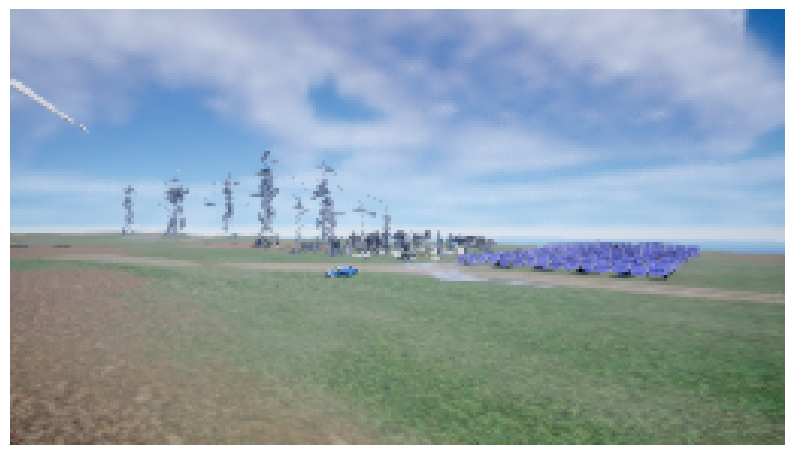

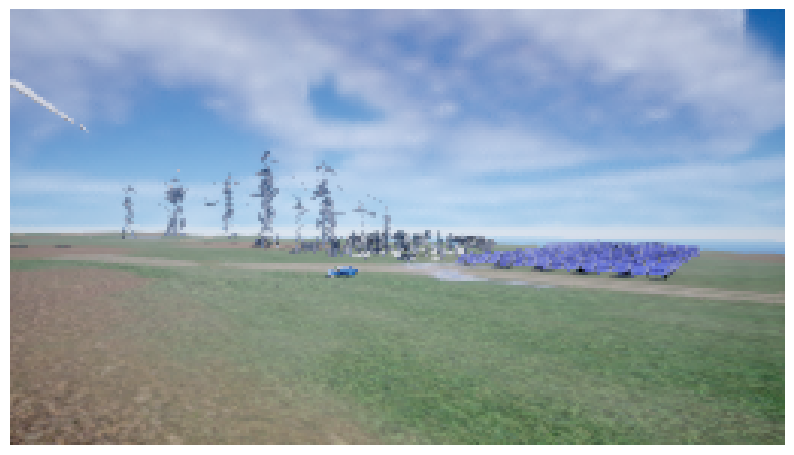

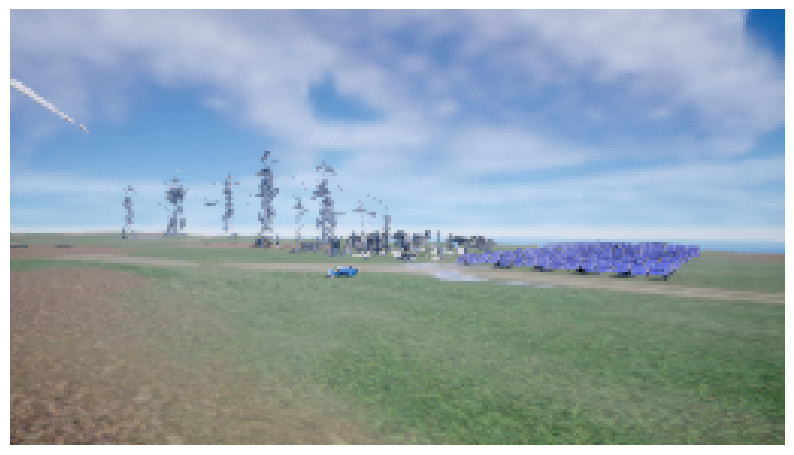

In [9]:
import time
import cv2
import matplotlib.pyplot as plt
# connect to the AirSim simulator
client2 = airsim.MultirotorClient()

#不需要解锁等操作，直接使用即可


camera_name = '0'  # 前向中间摄像头     
image_type = airsim.ImageType.Scene  # 彩色图airsim.ImageType.Scene, Infrared

for i in range(3):
    response = client2.simGetImage(camera_name, image_type, vehicle_name='')  # simGetImage接口的调用方式如下
    if response:  # 二进制图片数据
        # 转换成opencv图片格式
        img_bgr = cv2.imdecode(np.array(bytearray(response), dtype='uint8'), cv2.IMREAD_UNCHANGED)  # 从二进制图片数据中读
        
        # 将BGR格式转换为RGB格式，因为matplotlib默认显示RGB图像
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        
        # 在Jupyter Notebook中展示图片
        plt.figure(figsize=(10, 6))
        plt.imshow(img_rgb)
        plt.axis('off')
        plt.show()
        
    time.sleep(1)

相关配置参考文档：

https://microsoft.github.io/AirSim/sensors/

https://zhaoxuhui.top/blog/2021/12/01/airsim-note3-settings.html

访问后可自行配置无人机摄像机相关参数

# 实验任务
无人机自主巡航、拍照并返回起点降落锁定

任务描述

控制 AirSim 无人机完成：

1.连接仿真环境

2.获取 API 控制权

3.解锁无人机

4.起飞到 5 米高度

5.飞行到指定目标点(20,0,-5)

6.拍摄一张 RGB 图片

7.读取当前位置和姿态

8.返回起点

9.降落并锁定

In [1]:
import sys
sys.path.append('../external-libraries')
import airsim
import math
import numpy as np

In [2]:
#连接airsim模拟器并反馈连接状态，其中client = airsim.MultirotorClient()内可以写ip地址，不写默认连接本地，写了就是连接到目标地址的对应机器
client = airsim.MultirotorClient()
client.confirmConnection()
#获取API控制权限并查询
client.enableApiControl(True)
client.isApiControlEnabled()

Connected!
Client Ver:1 (Min Req: 1), Server Ver:1 (Min Req: 1)



True

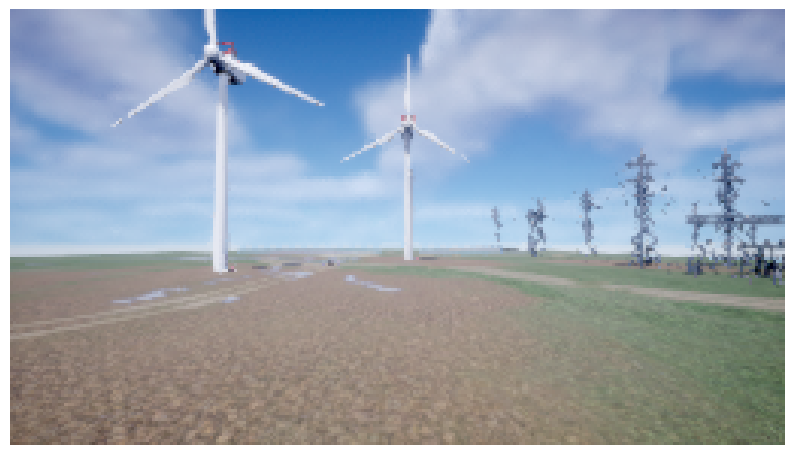

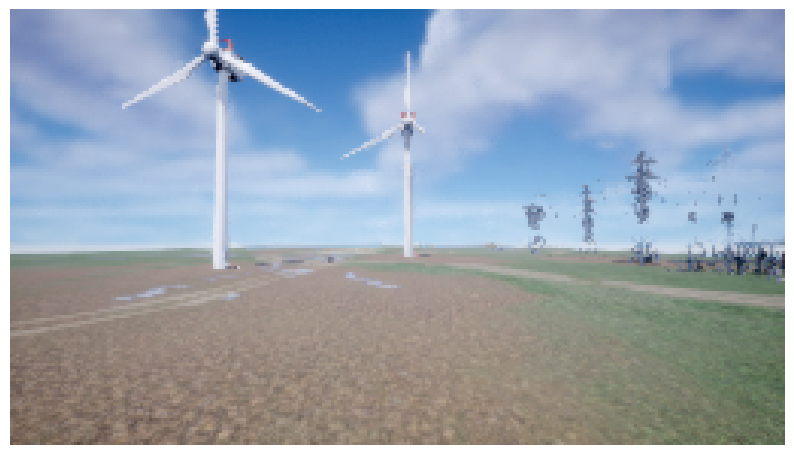

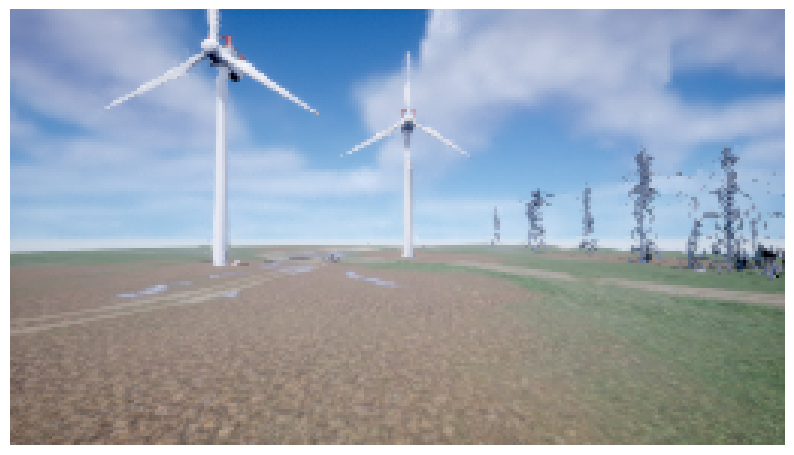

<Pose> {   'orientation': <Quaternionr> {   'w_val': 0.9999152421951294,
    'x_val': -1.742891275746672e-09,
    'y_val': 0.013019643723964691,
    'z_val': 1.300237641999047e-07},
    'position': <Vector3r> {   'x_val': 20.339099884033203,
    'y_val': 1.1722413262305054e-07,
    'z_val': -4.50986385345459}}
实验任务完成


In [3]:
#无人机起飞
client.takeoffAsync().join()

#飞到目标点（20，0，-5）
client.moveToPositionAsync(
    20,
    0,
    -5,
    1
).join()

#拍摄一张RGB照片
import cv2
import matplotlib.pyplot as plt

client2 = airsim.MultirotorClient()

camera_name = '0'  # 前向中间摄像头     
image_type = airsim.ImageType.Scene  # 彩色图airsim.ImageType.Scene, Infrared

for i in range(3):
    response = client2.simGetImage(camera_name, image_type, vehicle_name='')  # simGetImage接口的调用方式如下
    if response:  # 二进制图片数据
        # 转换成opencv图片格式
        img_bgr = cv2.imdecode(np.array(bytearray(response), dtype='uint8'), cv2.IMREAD_UNCHANGED)  # 从二进制图片数据中读
        
        # 将BGR格式转换为RGB格式，因为matplotlib默认显示RGB图像
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        
        # 在Jupyter Notebook中展示图片
        plt.figure(figsize=(10, 6))
        plt.imshow(img_rgb)
        plt.axis('off')
        plt.show()
        
#获取当前位置和姿态
pose = client.simGetVehiclePose()
print(pose)

#返回起点
client.moveToPositionAsync(
    0,
    0,
    -5,
    1
).join()

#降落并锁定
client.landAsync().join()
client.armDisarm(False)
client.enableApiControl(False)

print("实验任务完成")